# Exploratory Data Analysis

**Dataset:** [Heart Failure Prediction Dataset](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction)

**Source:** Combination of 5 heart disease datasets (Cleveland, Hungarian, Switzerland, Long Beach VA, Stalog)

---

### Table of Contents

1. [Setup & Data Loading](#1)
2. [Dataset Overview](#2)
3. [Data Quality Assessment](#3)
4. [Target Variable Distribution](#4)
5. [Univariate Analysis](#5)
6. [Bivariate Analysis: Features vs Target](#6)
7. [Correlation Analysis](#7)
8. [Statistical Testing](#10)
9. [Summary & Key Findings](#11)

<a id='1'></a>
## 1. Setup & Data Loading

Import required libraries and configure the global plotting style for consistent, publication-quality figures.

In [30]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, ttest_ind, mannwhitneyu, pointbiserialr
import warnings

# Global settings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 3)

# Plotting style
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)
PALETTE_TARGET = {"No Disease": "#3A86FF", "Disease": "#FF006E"}
FIG_DPI = 120
plt.rcParams.update({
    "figure.dpi": FIG_DPI,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "figure.titlesize": 16,
    "figure.titleweight": "bold",
})

In [31]:
# Load dataset
DATA_PATH = "data/raw/initial_dataset.csv"
df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")

Dataset loaded: 918 rows × 12 columns


<a id='2'></a>
## 2. Dataset Overview

The dataset consists of **11 clinical features** and **1 binary target** (`HeartDisease`).

| # | Feature | Type | Description |
|---|---------|------|-------------|
| 1 | `Age` | Numerical | Age of the patient (years) |
| 2 | `Sex` | Categorical | M: Male, F: Female |
| 3 | `ChestPainType` | Categorical | TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic |
| 4 | `RestingBP` | Numerical | Resting blood pressure (mm Hg) |
| 5 | `Cholesterol` | Numerical | Serum cholesterol (mm/dl) |
| 6 | `FastingBS` | Binary | 1 if fasting blood sugar > 120 mg/dl, 0 otherwise |
| 7 | `RestingECG` | Categorical | Normal, ST: ST-T wave abnormality, LVH: left ventricular hypertrophy |
| 8 | `MaxHR` | Numerical | Maximum heart rate achieved (60–202) |
| 9 | `ExerciseAngina` | Categorical | Y: Yes, N: No |
| 10 | `Oldpeak` | Numerical | ST depression (numeric) |
| 11 | `ST_Slope` | Categorical | Up: upsloping, Flat: flat, Down: downsloping |
| **Target** | `HeartDisease` | Binary | 1: heart disease, 0: normal |

In [32]:
# Firts 5 rows
print("First 5 rows:")
df.head()

First 5 rows:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [33]:
# Separate feature types
categorical_cols = df.select_dtypes(include="object").columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
numerical_cols.remove("HeartDisease")

print(f"Categorical features ({len(categorical_cols)}): {categorical_cols}")
print(f"Numerical features  ({len(numerical_cols)}): {numerical_cols}")

Categorical features (5): ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
Numerical features  (6): ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']


In [34]:
# Numerical summary
df[numerical_cols].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.51,9.43,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.40,18.51,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.80,109.38,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.23,0.42,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.81,25.46,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.89,1.07,-2.6,0.00,0.6,1.5,6.2


In [35]:
# Categorical summary
df[categorical_cols].describe().T

,count,unique,top,freq
Sex,918,2,M,725
ChestPainType,918,4,ASY,496
RestingECG,918,3,Normal,552
ExerciseAngina,918,2,N,547
ST_Slope,918,3,Flat,460


<a id='3'></a>
## 3. Data Quality Assessment

This section checks for missing values, duplicated rows, and anomalous zero-values that may indicate encoding errors in the original source datasets.

In [36]:
# Missing values
missing = df.isnull().sum()
if missing.sum() == 0:
    print("No missing values detected.")
else:
    missing_pct = (missing / len(df) * 100).round(2)
    missing_report = pd.DataFrame({"Missing": missing, "% Missing": missing_pct})
    missing_report = missing_report[missing_report["Missing"] > 0]
    display(missing_report)

No missing values detected.


In [37]:
# Duplicate rows
n_dupes = df.duplicated().sum()
if n_dupes == 0:
    print("No duplicate rows detected.")
else:
    print(f"Duplicate rows: {n_dupes} ({n_dupes / len(df) * 100:.1f}%)")

No duplicate rows detected.


In [39]:
# Zero values in numerical features
# FastingBS and Oldpeak are not included as 0 can be valid values (e.g. no fasting, no ST depression)
zero_check_cols = ["Age", "RestingBP", "Cholesterol", "MaxHR"]
zero_report = []
for col in zero_check_cols:
    n_zeros = (df[col] == 0).sum()
    pct = n_zeros / len(df) * 100
    zero_report.append({"Feature": col, "Zero Count": n_zeros, "% of Total": round(pct, 1)})

zero_df = pd.DataFrame(zero_report).set_index("Feature")
display(zero_df)

,Zero Count,% of Total
Feature,,
Age,0,0.0
RestingBP,0,0.0
Cholesterol,0,0.0
MaxHR,0,0.0


As highlighted by the table above, there are some values that are clinically impossible:

- *RestingBP* (Resting Blood Pressure): There is 1 record with a value of 0. A blood pressure of zero is biologically impossible for a living patient.

- *Cholesterol* (Serum Cholesterol): There are 172 records (nearly 19% of the dataset) with a value of 0. While very low cholesterol exists, an absolute 0 mg/dl is clinically invalid.

These zero values are clearly masked missing values (NaNs) entered during the data collection process.

**Action taken:** These zeros are replaced with `NaN` so that all subsequent analyses (distributions, correlations, statistical tests) automatically exclude them. This avoids artificially deflating means and inflating variances. Proper imputation, if needed, will be handled in the preprocessing phase.

In [41]:
# Replace clinically impossible zeros with NaN
# No imputation here (that belongs to the preprocessing step).
# Converting to NaN ensures all downstream statistics ignore these entries.
cols_to_fix = ["Cholesterol", "RestingBP"]
for col in cols_to_fix:
    n_before = (df[col] == 0).sum()
    df[col] = df[col].replace(0, np.nan)
    print(f"  {col}: {n_before} zeros -> NaN")

print(f"\nDataset shape unchanged: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Effective non-null counts: Cholesterol = {df['Cholesterol'].notna().sum()}, RestingBP = {df['RestingBP'].notna().sum()}")

  Cholesterol: 0 zeros -> NaN
  RestingBP: 0 zeros -> NaN

Dataset shape unchanged: 918 rows x 12 columns
Effective non-null counts: Cholesterol = 746, RestingBP = 917


<a id='4'></a>
## 4. Target Variable Distribution

Before exploring features, the balance of the target variable `HeartDisease` is examined.

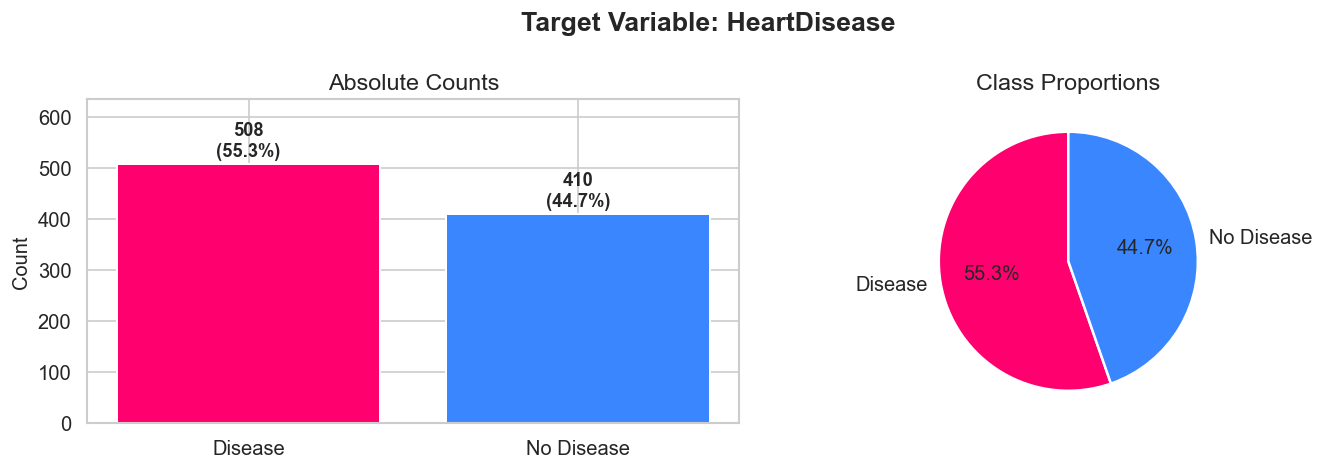

Imbalance ratio: 1.24:1
The dataset is reasonably balanced


In [58]:
# Target distribution
target_counts = df["HeartDisease"].value_counts().rename({0: "No Disease", 1: "Disease"})
target_pct = (target_counts / len(df) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Map each label to its correct colour
bar_colors = [PALETTE_TARGET[label] for label in target_counts.index]

# Count plot
bars = axes[0].bar(target_counts.index, target_counts.values,
                   color=bar_colors,
                   edgecolor="white", linewidth=1.2)
for bar, pct in zip(bars, target_pct.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 8,
                 f"{int(bar.get_height())}\n({pct}%)",
                 ha="center", va="bottom", fontsize=11, fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].set_title("Absolute Counts")
axes[0].set_ylim(0, target_counts.max() * 1.25)

# Pie chart
axes[1].pie(target_counts.values, labels=target_counts.index,
            colors=bar_colors,
            autopct="%1.1f%%", startangle=90, textprops={"fontsize": 12},
            wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axes[1].set_title("Class Proportions")

fig.suptitle("Target Variable: HeartDisease")
plt.tight_layout()
plt.show()

ratio = target_counts.max() / target_counts.min()
print(f"Imbalance ratio: {ratio:.2f}:1")
if ratio < 1.5:
    print("The dataset is reasonably balanced")
else:
    print("Imbalance detected")

<a id='5'></a>
## 5. Univariate Analysis

This section explores the distribution of each categorical variable independently before examining its relationship with the target.

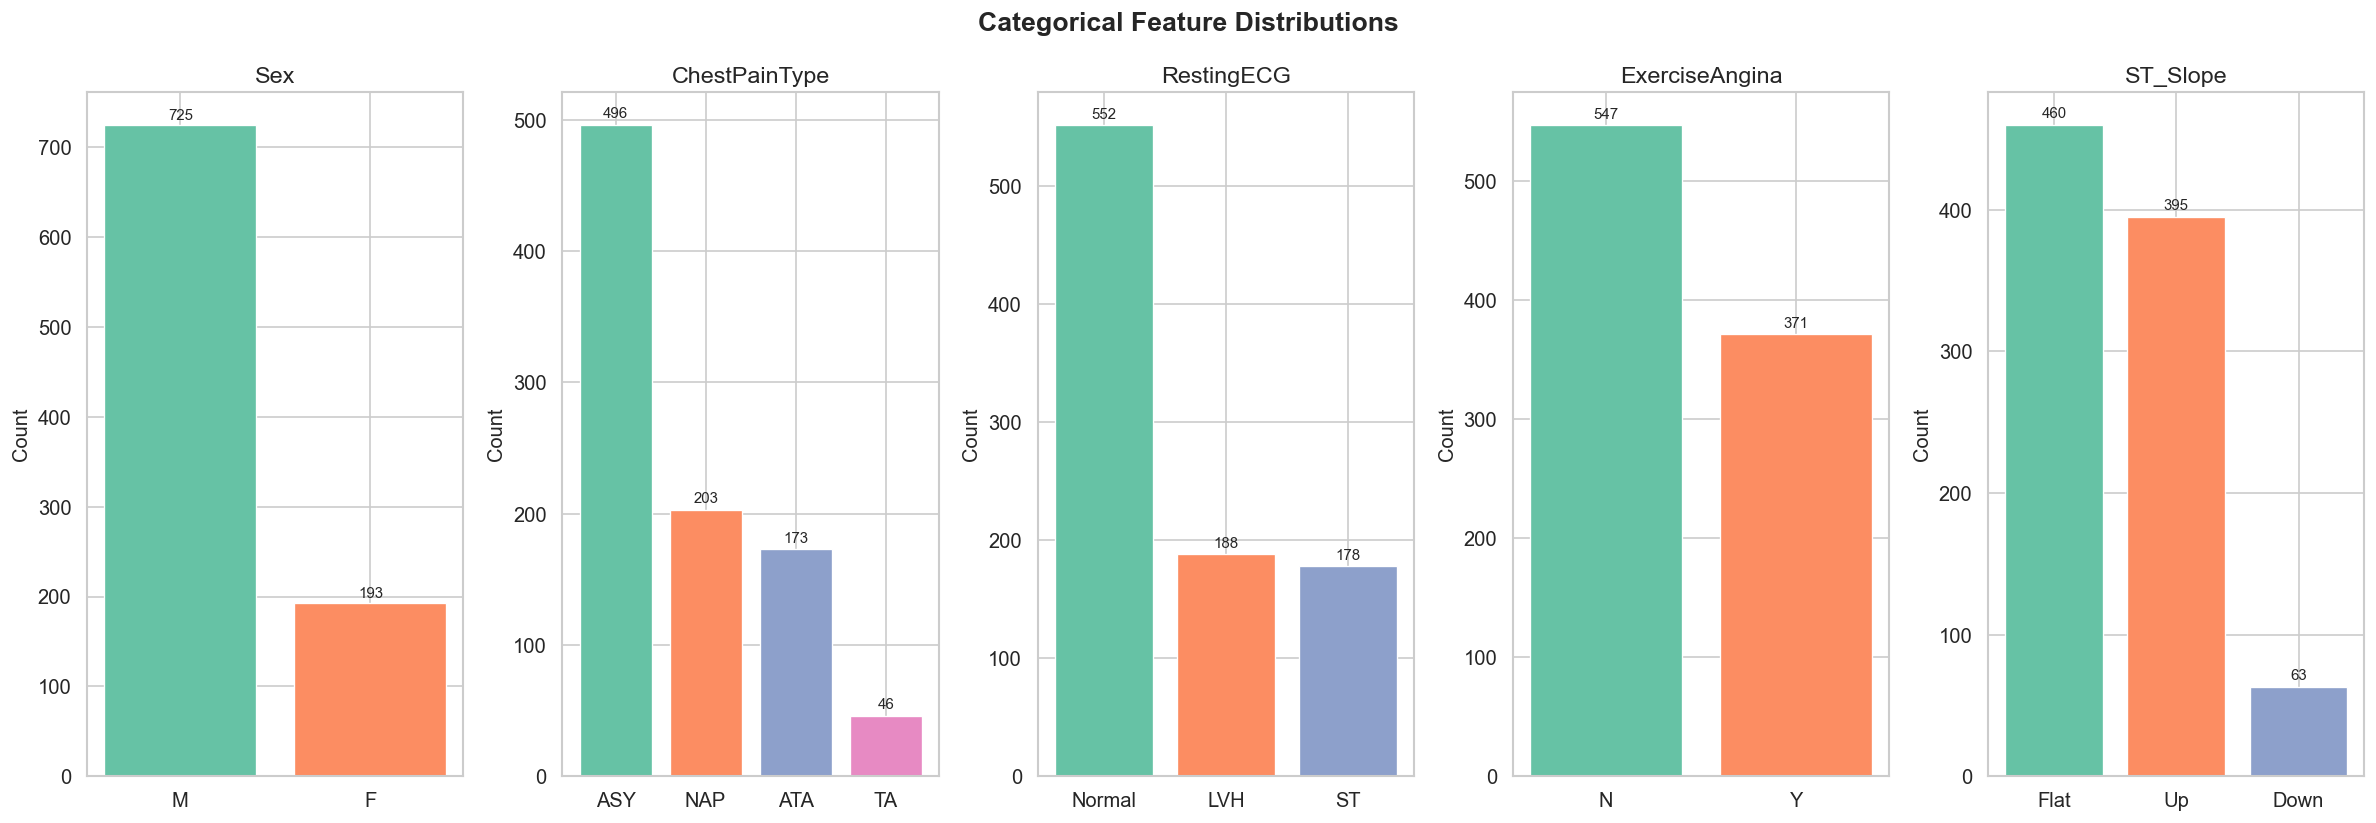

In [45]:
# Categorical feature distributions
n_cat = len(categorical_cols)
fig, axes = plt.subplots(1, n_cat, figsize=(4 * n_cat, 7), sharey=False)

for ax, col in zip(axes, categorical_cols):
    counts = df[col].value_counts()
    bars = ax.bar(counts.index, counts.values,
                  color=sns.color_palette("Set2", n_colors=len(counts)),
                  edgecolor="white", linewidth=0.8)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 3,
                f"{int(h)}", ha="center", va="bottom", fontsize=9)
    ax.set_title(col)
    ax.set_ylabel("Count")

fig.suptitle("Categorical Feature Distributions")
plt.tight_layout()
plt.show()

Histograms with overlaid KDE curves reveal the shape of each numerical distribution, helping identify skewness and potential outliers.

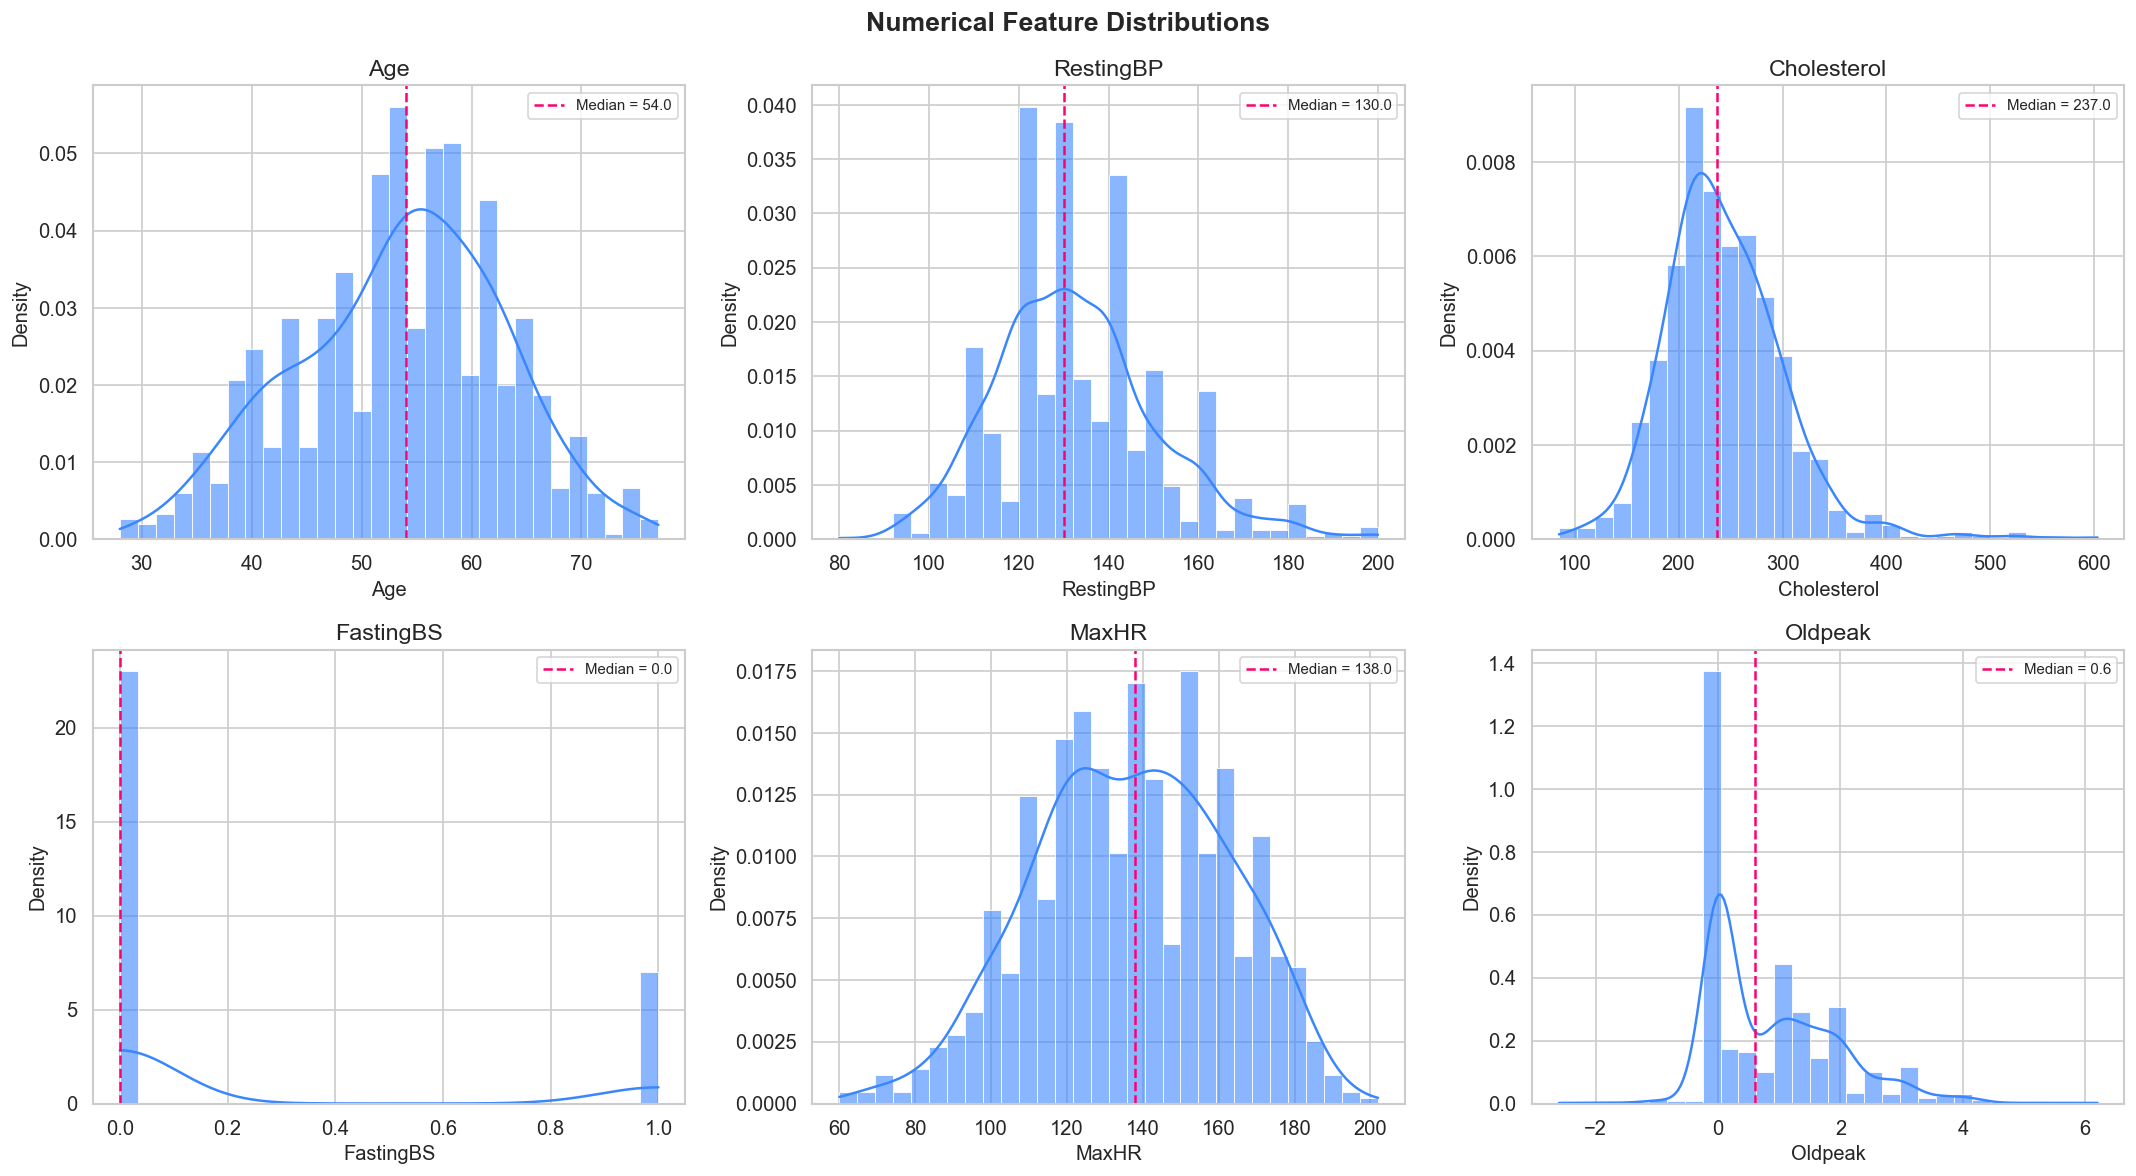

In [46]:
# Numerical feature distributions
n_num = len(numerical_cols)
n_rows = (n_num + 2) // 3

fig, axes = plt.subplots(n_rows, 3, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    ax = axes[idx]
    sns.histplot(df[col], kde=True, ax=ax, color="#3A86FF", edgecolor="white",
                 stat="density", bins=30, alpha=0.6, linewidth=0.5)
    ax.axvline(df[col].median(), color="#FF006E", linestyle="--", linewidth=1.5, label=f"Median = {df[col].median():.1f}")
    ax.set_title(col)
    ax.legend(fontsize=9)

# Hide unused subplots
for idx in range(n_num, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle("Numerical Feature Distributions")
plt.tight_layout()
plt.show()

### Observations: Univariate Analysis

**Categorical features:**

| Feature | Distribution |
|---------|-------------|
| **Sex** | Heavily imbalanced towards males (~725 M vs ~193 F), reflecting clinical recruitment bias. |
| **ChestPainType** | Dominated by asymptomatic (ASY) patients, followed by non-anginal pain (NAP). |
| **RestingECG** | Mostly normal, with smaller ST and LVH groups. |
| **ExerciseAngina** | Splits roughly 50/50 between Y and N. |
| **ST_Slope** | Predominantly Flat and Up, with very few Down cases. |

**Numerical features:**

| Feature | Distribution |
|---------|-------------|
| **Age** | Roughly normal, centred around 53–55 years. |
| **RestingBP** | Approximately normal (median ≈ 130 mm Hg), with mild right skewness. |
| **Cholesterol** | After zero removal, unimodal around 230–240 mg/dl with a right tail of high values. |
| **FastingBS** | Binary (0/1) — most patients have fasting blood sugar ≤ 120 mg/dl. |
| **MaxHR** | Broad distribution spanning ~60–200, with a slight left skew. |
| **Oldpeak** | Heavily right-skewed: most values clustered near 0 with a long tail towards 6. |

<a id='6'></a>
## 6. Bivariate Analysis: Features vs. Target

For each categorical feature, two complementary views are computed:

| View | Formula | Question answered |
|------|---------|-------------------|
| **Risk (left)** | $P(\text{Disease} \mid \text{Category})$ | *"Given this category, what is the probability of disease?"* |
| **Profile (right)** | $P(\text{Category} \mid \text{Disease})$ | *"Among diseased patients, how are categories distributed?"* |

In [47]:
# Helper: annotate bars
def annotate_bars(ax, fmt="{:.1%}", pad=4, fontsize=10, color="black"):
    """Add formatted labels on top of each bar."""
    for p in ax.patches:
        h = p.get_height()
        if np.isnan(h):
            continue
        ax.annotate(fmt.format(h),
                    xy=(p.get_x() + p.get_width() / 2, h),
                    xytext=(0, pad), textcoords="offset points",
                    ha="center", va="bottom", fontsize=fontsize, color=color)

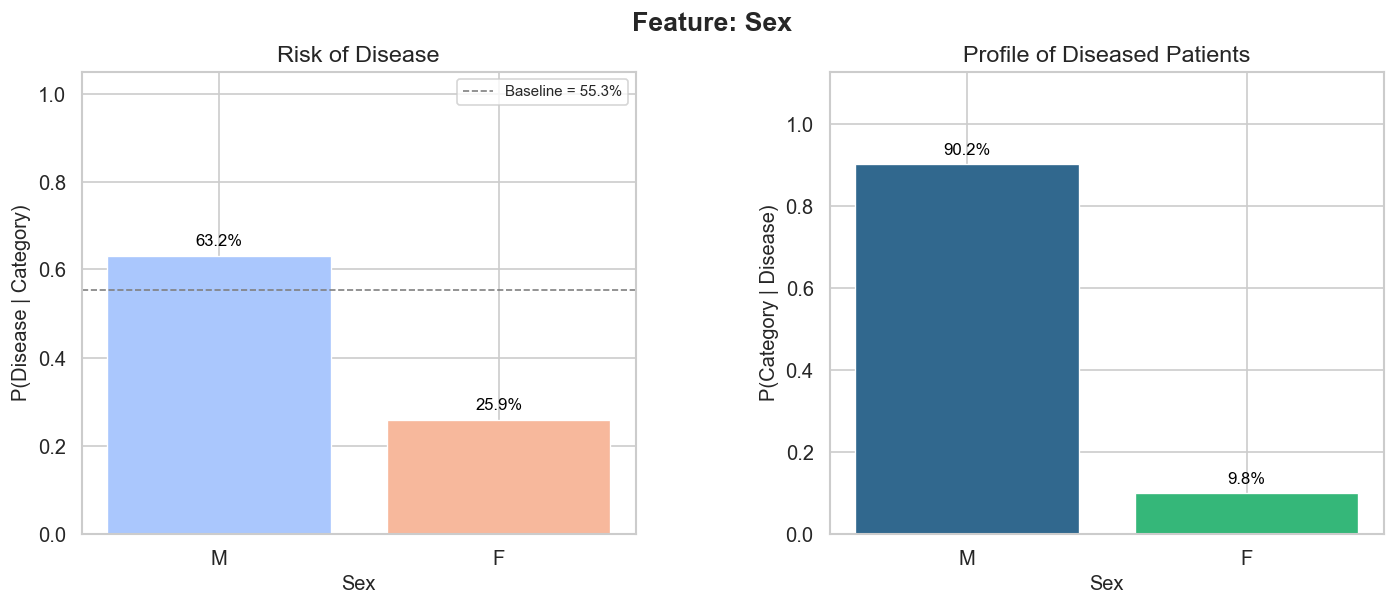

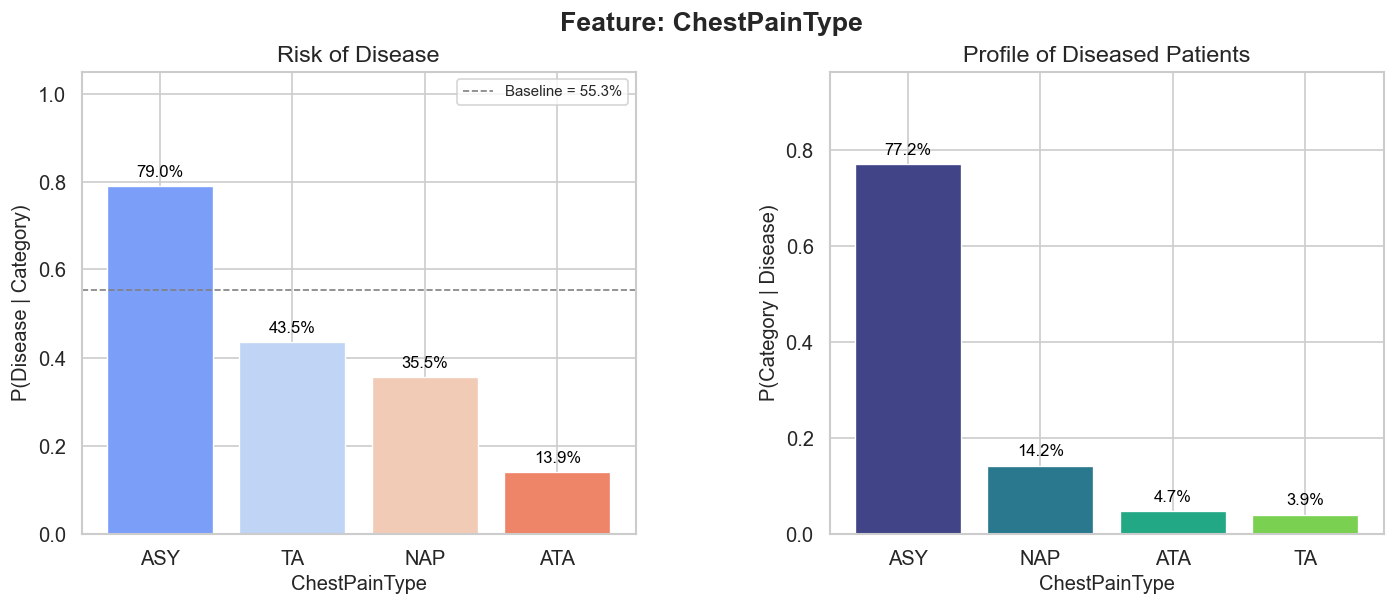

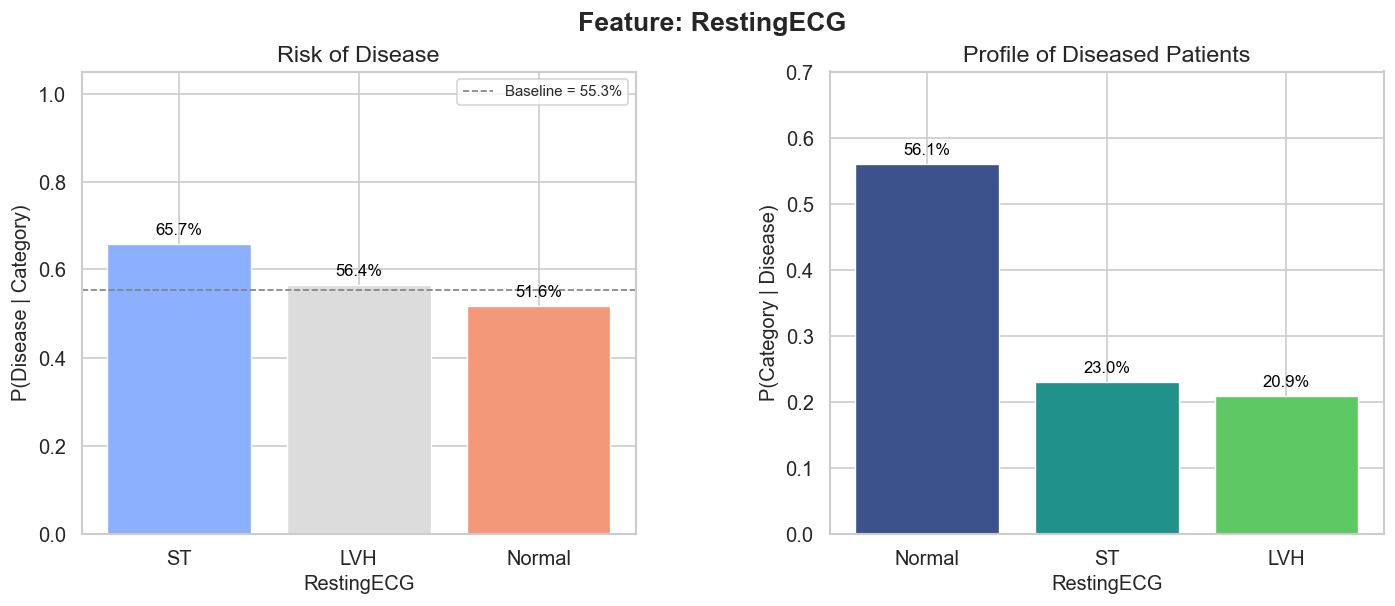

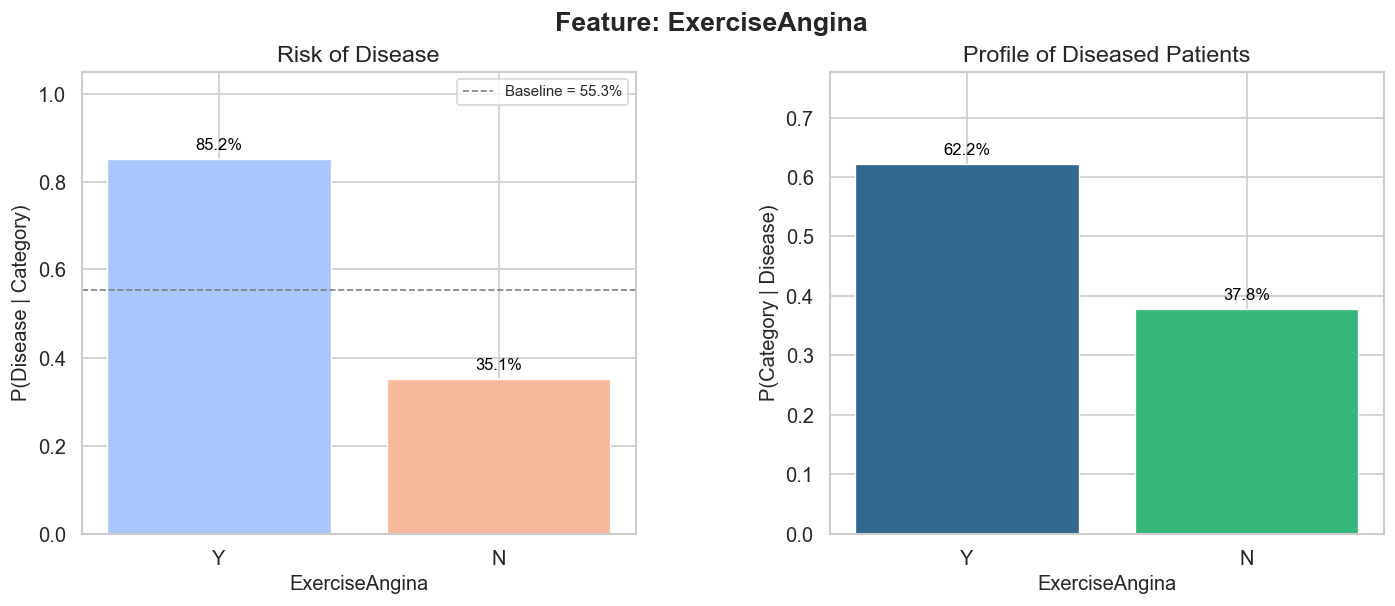

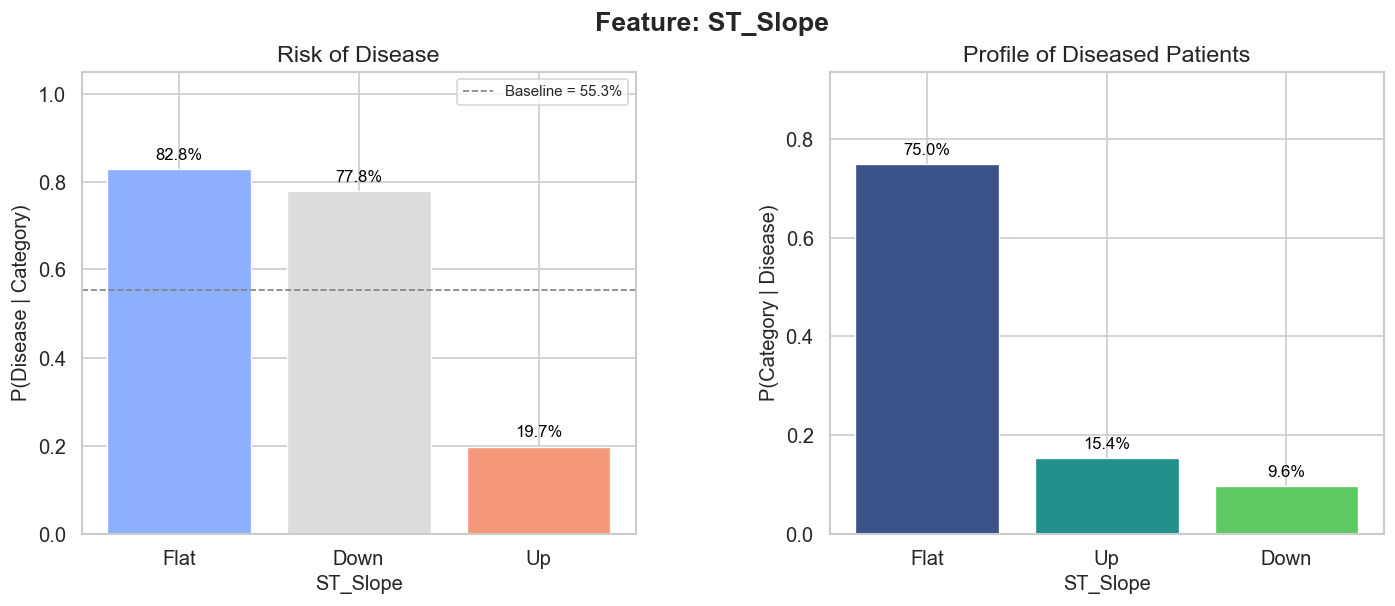

In [48]:
# Categorical features vs. HeartDisease
for col in categorical_cols:
    risk = df.groupby(col)["HeartDisease"].mean().sort_values(ascending=False)
    profile = (
        df.groupby("HeartDisease")[col]
          .value_counts(normalize=True)
          .loc[1]
          .sort_values(ascending=False)
    )

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"wspace": 0.35})

    # Risk plot
    colors_risk = sns.color_palette("coolwarm", n_colors=len(risk))
    ax1.bar(risk.index, risk.values, color=colors_risk, edgecolor="white", linewidth=0.8)
    ax1.set_ylabel("P(Disease | Category)")
    ax1.set_xlabel(col)
    ax1.set_title("Risk of Disease")
    ax1.set_ylim(0, 1.05)
    ax1.axhline(df["HeartDisease"].mean(), color="grey", linestyle="--",
                linewidth=1, label=f"Baseline = {df['HeartDisease'].mean():.1%}")
    ax1.legend(fontsize=9)
    annotate_bars(ax1)

    # Profile plot
    colors_prof = sns.color_palette("viridis", n_colors=len(profile))
    ax2.bar(profile.index, profile.values, color=colors_prof, edgecolor="white", linewidth=0.8)
    ax2.set_ylabel("P(Category | Disease)")
    ax2.set_xlabel(col)
    ax2.set_title("Profile of Diseased Patients")
    ax2.set_ylim(0, max(profile.values) * 1.25)
    annotate_bars(ax2)

    fig.suptitle(f"Feature: {col}")
    plt.tight_layout()
    plt.show()

### Observations: Categorical Features

| Feature | Key Finding |
|---------|-------------|
| **Sex** | Males (63.2%) have a significantly higher risk than Females (25.9%). The diseased population is overwhelmingly male (90.2%). |
| **ChestPainType** | Asymptomatic (ASY) pain carries the highest risk (79.0%); Atypical Angina (ATA) is the safest (13.9%). 77.2% of diseased patients present with ASY. |
| **RestingECG** | All categories show similar risk (52–66%). This appears to be a weak predictor. Notably, 56.1% of diseased patients had a normal ECG. |
| **ExerciseAngina** | Exercise-induced angina (Y) is a very strong predictor: 85.2% risk. 62.2% of diseased patients are positive. |
| **ST_Slope** | 'Flat' (82.8%) and 'Down' (77.8%) are extremely high-risk. An 'Up' slope indicates health (only 19.7% risk). |

The following plots compare distributions (KDE) and medians/spreads (box plots, violin plots) between the two outcome groups.

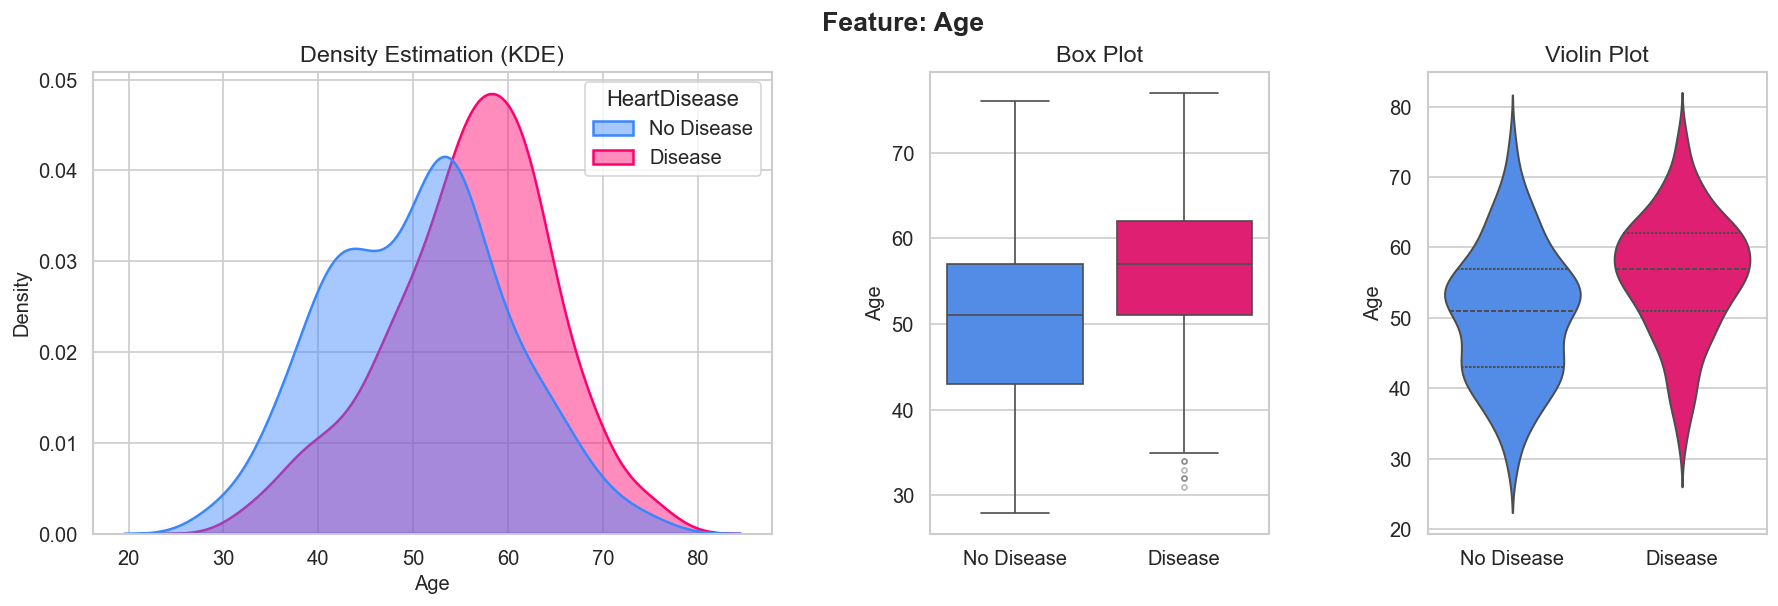

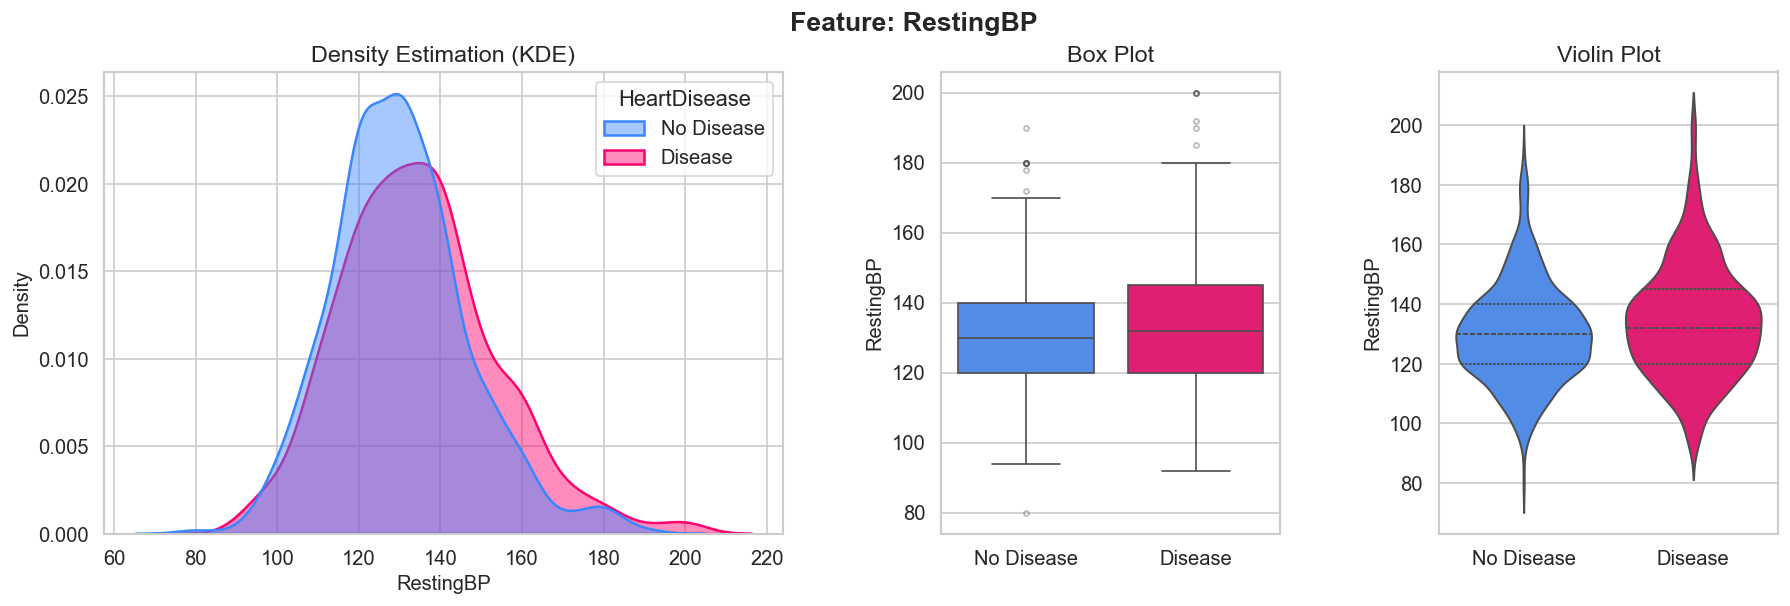

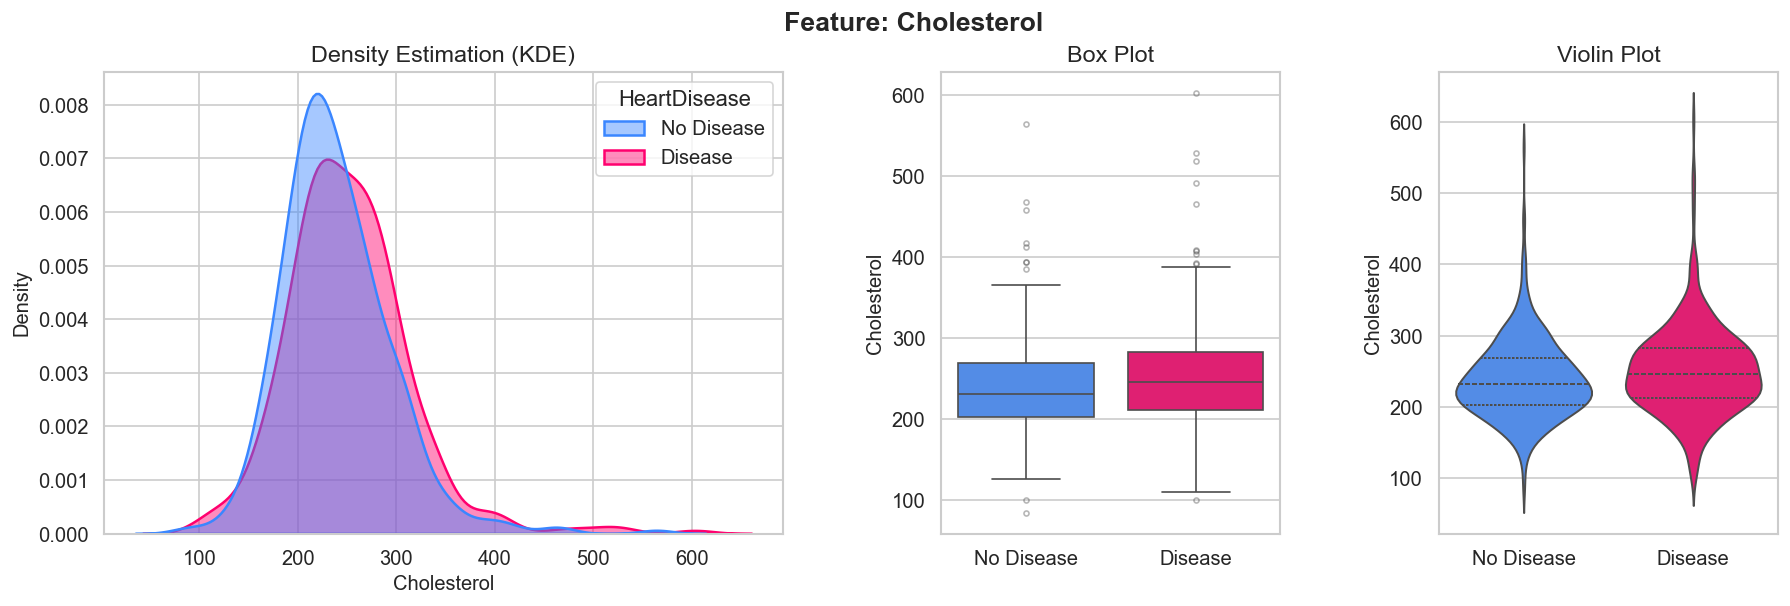

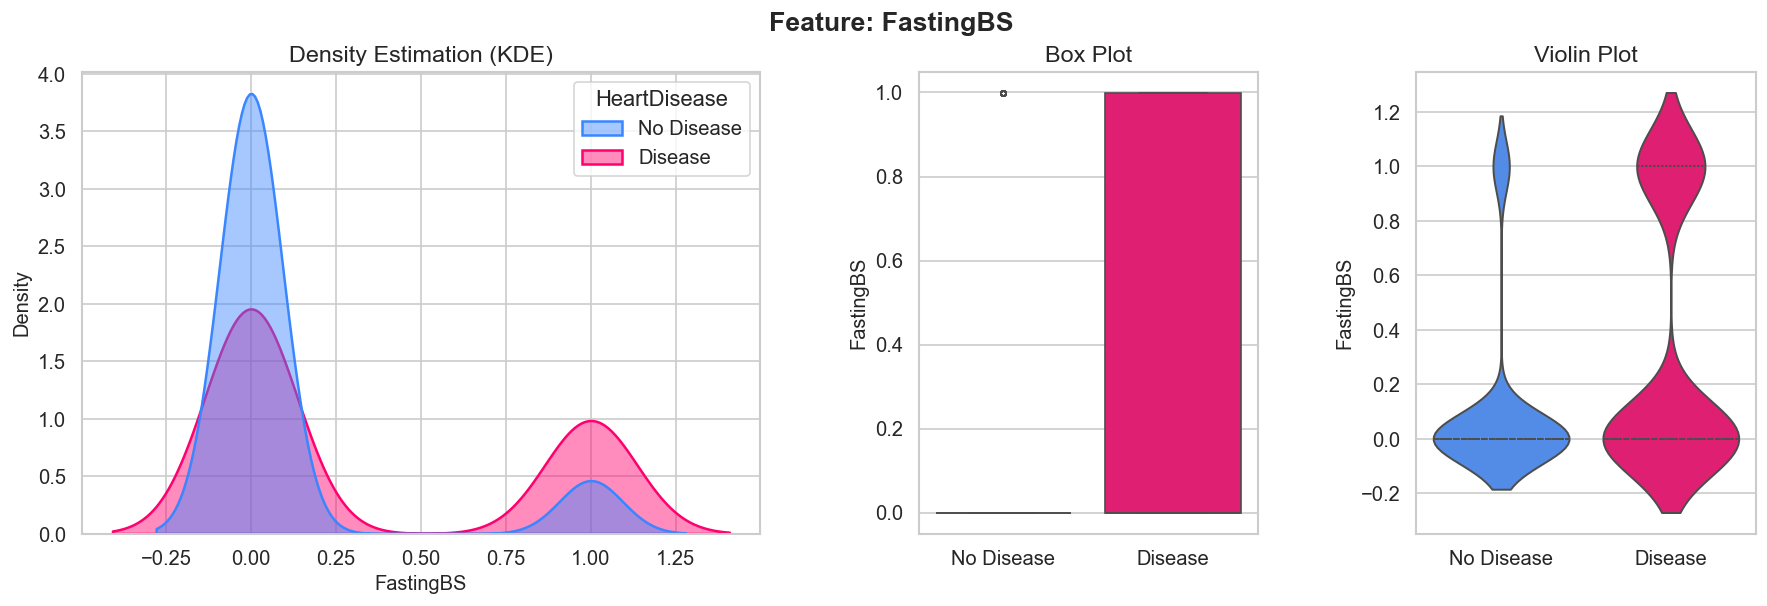

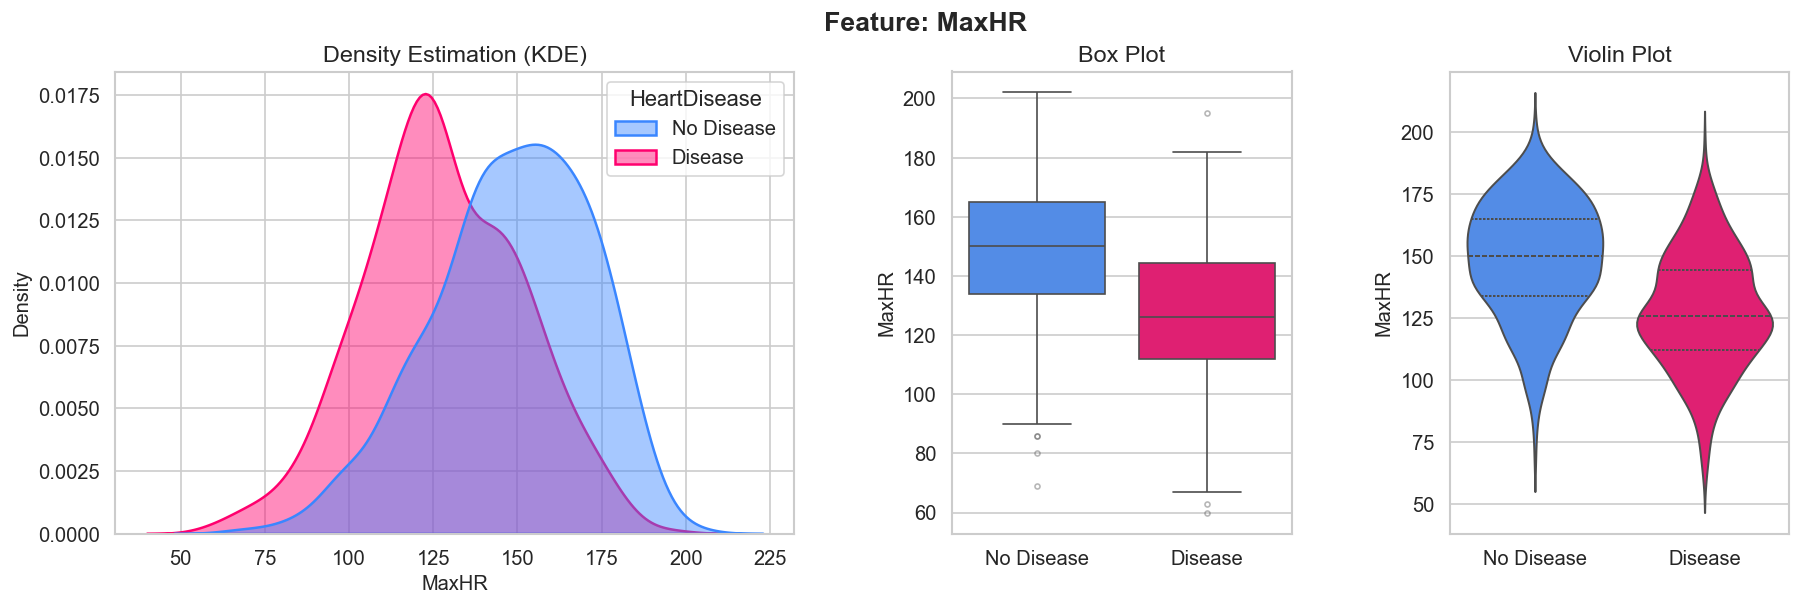

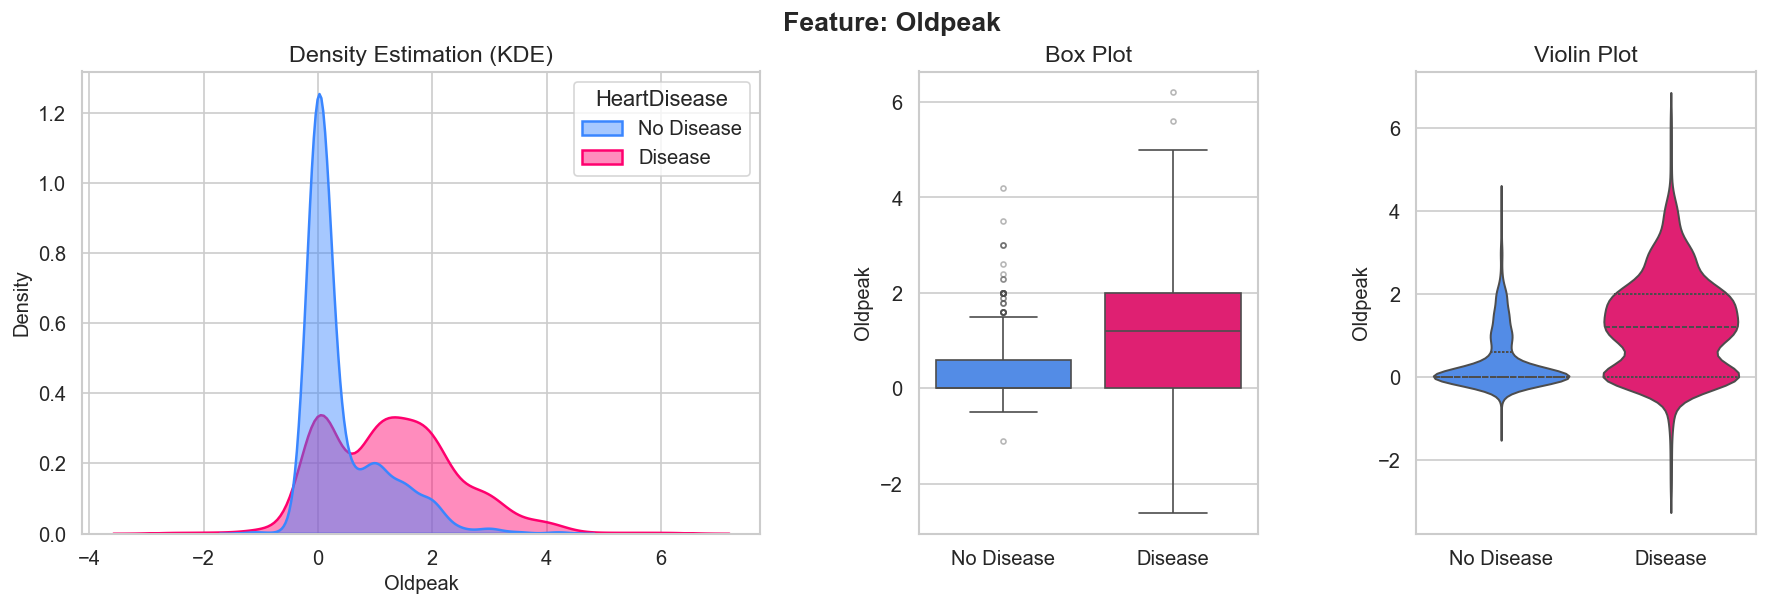

In [18]:
# Numerical features vs. HeartDisease
target_labels = df["HeartDisease"].map({0: "No Disease", 1: "Disease"})
target_labels.name = "HeartDisease"

hue_order = ["No Disease", "Disease"]

for col in numerical_cols:
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5),
                                         gridspec_kw={"width_ratios": [2, 1, 1], "wspace": 0.35})

    # KDE
    sns.kdeplot(data=df, x=col, hue=target_labels, fill=True, common_norm=False,
                palette=PALETTE_TARGET, ax=ax1, hue_order=hue_order, alpha=0.45, linewidth=1.5)
    ax1.set_title("Density Estimation (KDE)")
    ax1.set_ylabel("Density")

    # Box plot
    sns.boxplot(data=df, x=target_labels, y=col, palette=PALETTE_TARGET,
                hue=target_labels, legend=False, ax=ax2, order=hue_order,
                flierprops={"marker": "o", "markersize": 3, "alpha": 0.4})
    ax2.set_title("Box Plot")
    ax2.set_xlabel("")

    # Violin plot
    sns.violinplot(data=df, x=target_labels, y=col, palette=PALETTE_TARGET,
                   hue=target_labels, legend=False, ax=ax3, order=hue_order,
                   inner="quartile", linewidth=1.2)
    ax3.set_title("Violin Plot")
    ax3.set_xlabel("")

    fig.suptitle(f"Feature: {col}")
    plt.tight_layout()
    plt.show()

### Observations: Numerical Features

| Feature | Key Finding |
|---------|-------------|
| **Age** | The Disease group distribution is shifted right: median age is visibly higher than in the No Disease group. |
| **MaxHR** | Clear separation between groups: the Disease group peaks at a lower MaxHR, indicating that lower maximum heart rate is associated with disease. |
| **Oldpeak** | Strong discriminator — the Disease group has a higher median and wider spread compared to No Disease. |
| **FastingBS** | The Disease group has a much larger proportion at 1 (fasting blood sugar > 120 mg/dl) than the No Disease group. |
| **Cholesterol** | After zero-artefact removal (§3), the two groups show only modest separation. Discriminative power to be re-evaluated after imputation. |
| **RestingBP** | The two distributions almost perfectly overlap. Weak discriminator between the two groups. |

<a id='7'></a>
## 7. Correlation Analysis

Categorical variables are one-hot encoded and a Pearson correlation matrix is computed. The analysis has two goals:

1. **Feature → Target:** Identify which features are most correlated with `HeartDisease`.
2. **Feature → Feature (Multicollinearity):** Detect pairs of features that are highly correlated with *each other* ($|r| > 0.7$). High multicollinearity can inflate variance in linear models (e.g. Logistic Regression) and should be addressed in the modelling phase.

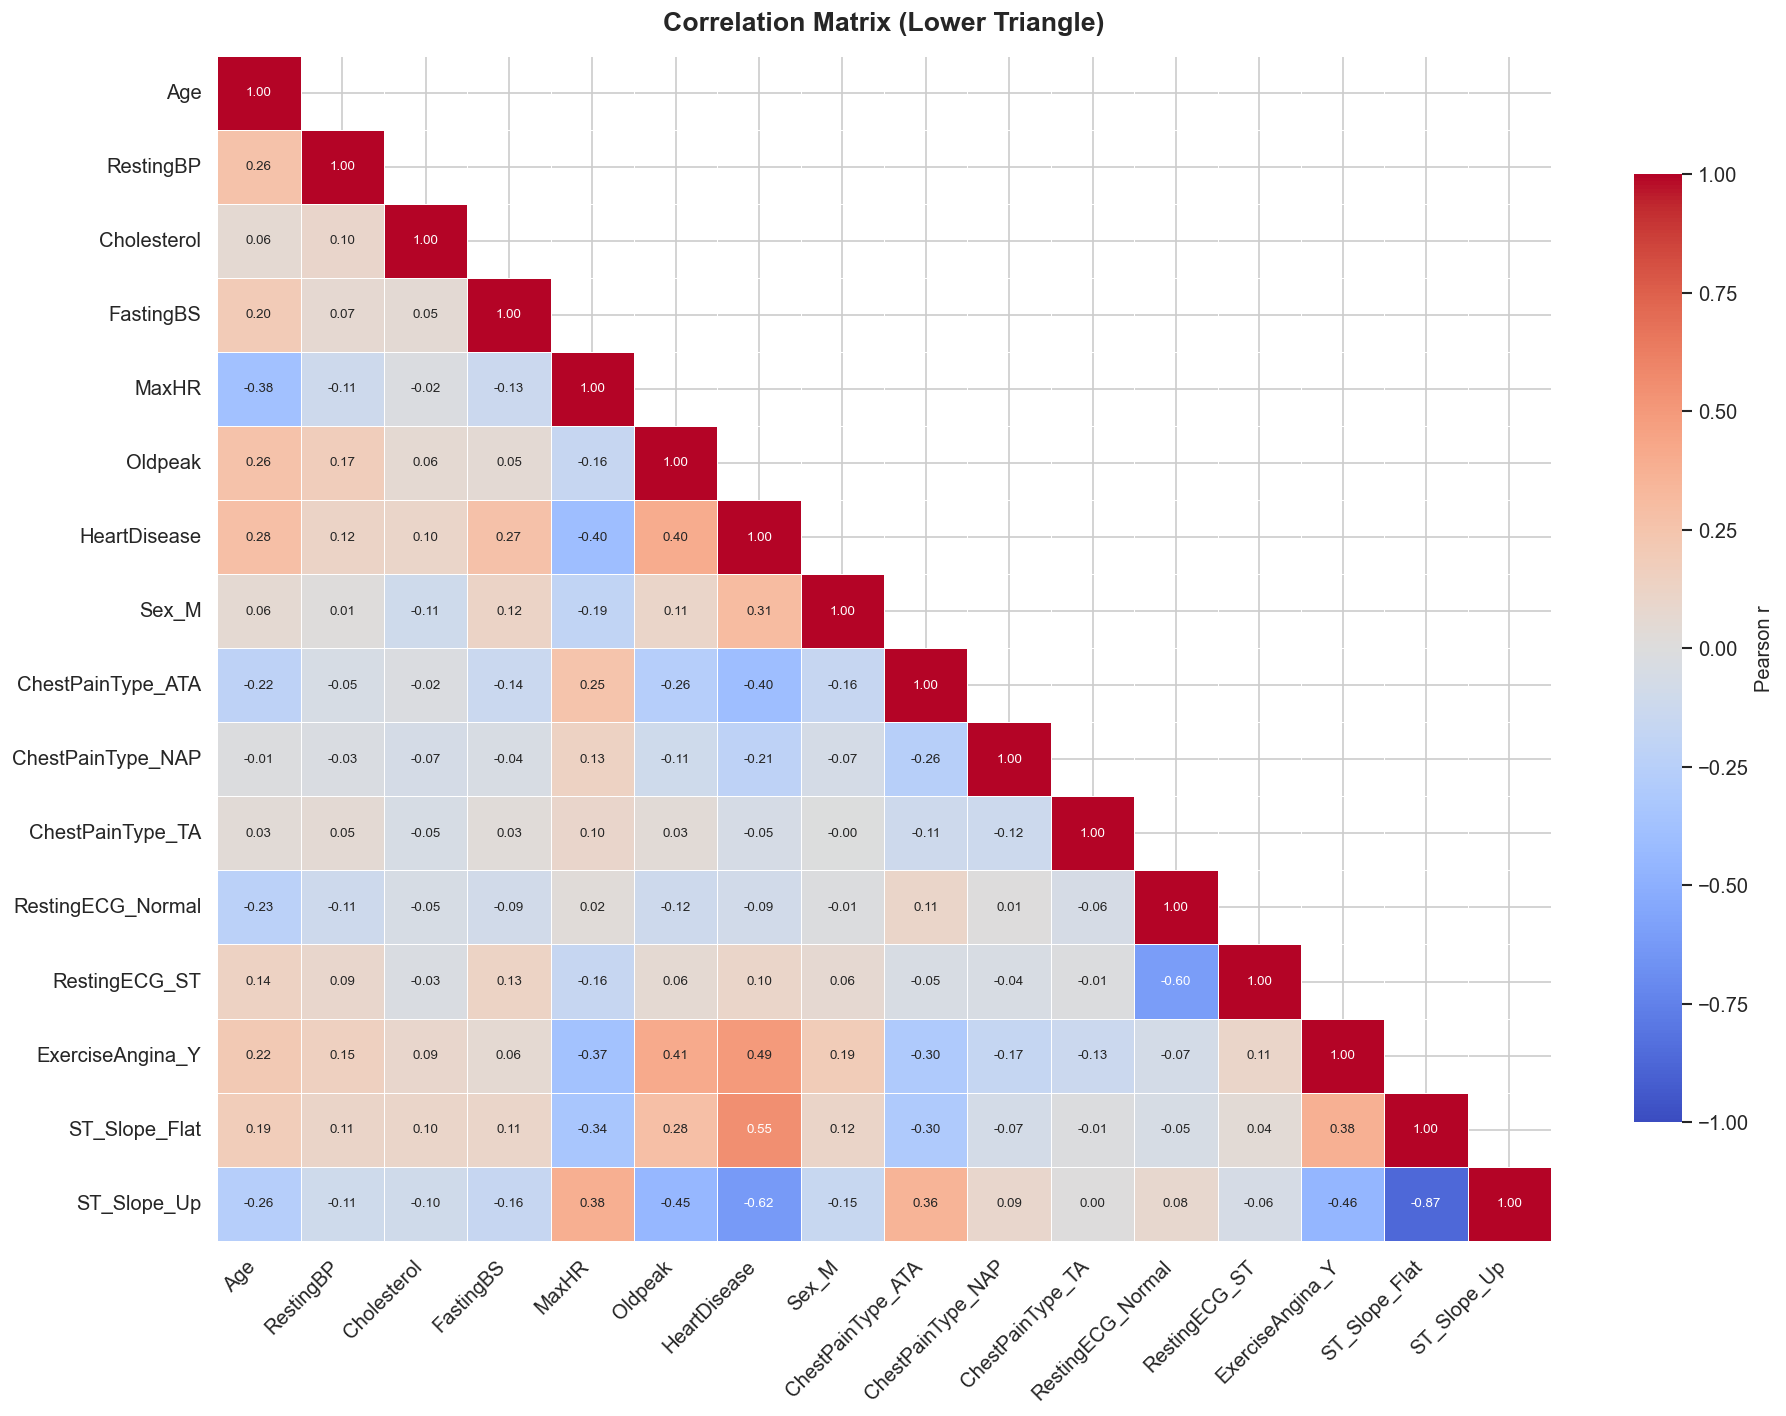

In [49]:
# Correlation matrix (full, one-hot encoded)
df_encoded = pd.get_dummies(df, drop_first=True)
corr_matrix = df_encoded.corr()

# Mask upper triangle for cleaner visualisation
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap="coolwarm", fmt=".2f",
            linewidths=0.5, annot_kws={"size": 8}, vmin=-1, vmax=1,
            cbar_kws={"shrink": 0.8, "label": "Pearson r"}, ax=ax)
ax.set_title("Correlation Matrix (Lower Triangle)", fontsize=16, fontweight="bold", pad=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

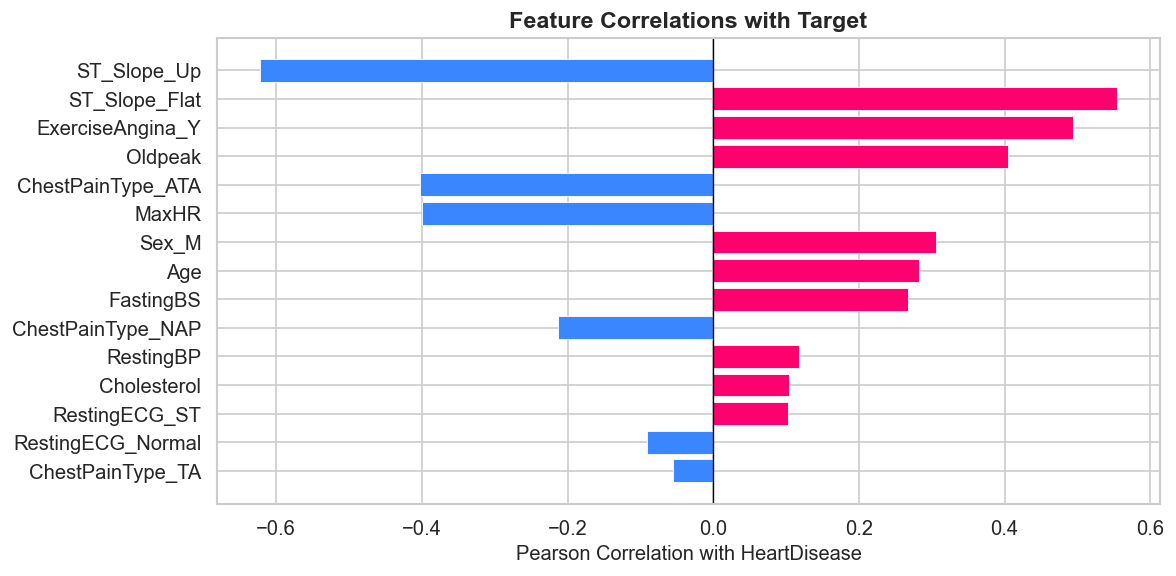


Top correlations with HeartDisease:


,Correlation
ST_Slope_Up,-0.622
ST_Slope_Flat,0.554
ExerciseAngina_Y,0.494
Oldpeak,0.404
ChestPainType_ATA,-0.402
MaxHR,-0.400
Sex_M,0.305
Age,0.282
FastingBS,0.267
ChestPainType_NAP,-0.213


In [51]:
# Top correlations with HeartDisease
target_corr = (
    corr_matrix["HeartDisease"]
    .drop("HeartDisease")
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#FF006E" if v > 0 else "#3A86FF" for v in target_corr.values]
ax.barh(target_corr.index[::-1], target_corr.values[::-1], color=colors[::-1],
        edgecolor="white", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson Correlation with HeartDisease")
ax.set_title("Feature Correlations with Target", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nTop correlations with HeartDisease:")
display(target_corr.to_frame("Correlation").style.format("{:.3f}").bar(
    subset=["Correlation"], color=["#3A86FF", "#FF006E"], align="zero"))

### Correlation Insights

**Feature → Target:**

| Strength | Feature | Correlation | Interpretation |
|----------|---------|-------------|----------------|
| **Strong –** | `ST_Slope_Up` | ≈ −0.62 | Upsloping ST strongly associated with health |
| **Strong +** | `ST_Slope_Flat` | ≈ +0.55 | Flat ST strongly associated with disease |
| **Moderate +** | `ExerciseAngina_Y` | ≈ +0.49 | Exercise-induced angina indicates disease |
| **Moderate +** | `Oldpeak` | ≈ +0.40 | Higher ST depression linked to disease |
| **Moderate –** | `MaxHR` | ≈ −0.40 | Lower max HR linked to disease |
| **Weak +** | `Sex_M` | ≈ +0.31 | Male sex is a risk factor |
| **Weak** | `RestingBP`, `Cholesterol` | < 0.15 | Weak linear predictors individually |

### Multicollinearity Check (Feature ↔ Feature)

High correlation between pairs of **predictor** variables (multicollinearity) can inflate coefficient variance in linear models (e.g. Logistic Regression) and make individual feature importance unreliable. Any pair with $|r| > 0.7$ is flagged below.

In [55]:
# Multicollinearity: feature-feature correlations (excluding HeartDisease)
feature_corr = corr_matrix.drop(index="HeartDisease", columns="HeartDisease")

# Extract upper triangle pairs with |r| > threshold
THRESHOLD = 0.7
high_corr_pairs = []
for i in range(len(feature_corr.columns)):
    for j in range(i + 1, len(feature_corr.columns)):
        r = feature_corr.iloc[i, j]
        if abs(r) > THRESHOLD:
            high_corr_pairs.append({
                "Feature A": feature_corr.columns[i],
                "Feature B": feature_corr.columns[j],
                "Pearson r": round(r, 3),
            })

if high_corr_pairs:
    print(f"{len(high_corr_pairs)} feature pair(s) with |r| > {THRESHOLD}:\n")
    display(pd.DataFrame(high_corr_pairs))
else:
    print(f"No feature pairs exceed |r| > {THRESHOLD}.")

# Also show the top-10 strongest feature-feature correlations for reference
pairs = []
for i in range(len(feature_corr.columns)):
    for j in range(i + 1, len(feature_corr.columns)):
        pairs.append({
            "Feature A": feature_corr.columns[i],
            "Feature B": feature_corr.columns[j],
            "|Pearson r|": abs(feature_corr.iloc[i, j]),
            "Pearson r": round(feature_corr.iloc[i, j], 3),
        })

top_pairs = pd.DataFrame(pairs).sort_values("|Pearson r|", ascending=False).head(10).reset_index(drop=True)
top_pairs.index += 1
print("\nTop-10 strongest feature-feature correlations:")
display(top_pairs[["Feature A", "Feature B", "Pearson r"]])

1 feature pair(s) with |r| > 0.7:



,Feature A,Feature B,Pearson r
0,ST_Slope_Flat,ST_Slope_Up,-0.871



Top-10 strongest feature-feature correlations:


,Feature A,Feature B,Pearson r
1,ST_Slope_Flat,ST_Slope_Up,-0.871
2,RestingECG_Normal,RestingECG_ST,-0.602
3,ExerciseAngina_Y,ST_Slope_Up,-0.456
4,Oldpeak,ST_Slope_Up,-0.451
5,Oldpeak,ExerciseAngina_Y,0.409
6,MaxHR,ST_Slope_Up,0.383
7,ExerciseAngina_Y,ST_Slope_Flat,0.382
8,Age,MaxHR,-0.382
9,MaxHR,ExerciseAngina_Y,-0.370
10,ChestPainType_ATA,ST_Slope_Up,0.358


### Multicollinearity Interpretation

The only feature pair exceeding the $|r| > 0.7$ threshold is **`ST_Slope_Flat` ↔ `ST_Slope_Up`** ($r = -0.87$). This is a structural artefact of one-hot encoding: both dummies originate from the same categorical variable (`ST_Slope`), so one is nearly the algebraic inverse of the other. Using `drop_first=True` during encoding automatically eliminates this redundancy.

Among the remaining top-10 pairs, all correlations stay below $|r| = 0.61$, indicating that **no concerning multicollinearity exists among the original features**. Linear models can therefore be fitted without variance-inflation issues.

<a id='8'></a>
## 8. Statistical Testing

Formal hypothesis tests are applied to quantify the statistical significance of the observed differences.

| Test | Applied to | Null Hypothesis ($H_0$) | Note |
|------|-----------|-------------------------|------|
| **Welch's t-test** | Numerical features | The means of the two groups are equal | Parametric — assumes approximately normal distributions |
| **Mann–Whitney U test** | Numerical features | The distributions of the two groups are identical | Non-parametric — **no normality assumption**; robust for skewed variables (e.g. `Oldpeak`, `Cholesterol`) |
| **Point-Biserial correlation** | Numerical features | No linear association between the continuous variable and the binary target | Quantifies the **strength** of the association ($r_{pb} \in [-1, 1]$) |
| **Chi-squared test** | Categorical features | The feature and HeartDisease are independent | Tests association significance |
| **Cramér's V** | Categorical features | — | Effect size of the association ($V \in [0, 1]$) |

Significance level: $\alpha = 0.05$

**Why three tests for numerical features?**
- The **t-test** indicates *whether* a statistically significant difference in means exists between the two groups.
- The **Mann–Whitney U** test confirms this result without relying on the normality assumption — this is especially important for variables with heavy skewness (e.g. `Oldpeak`, `Cholesterol`), where the t-test may lose reliability.
- The **Point-Biserial correlation** goes further: it *quantifies how strongly* each continuous variable is linearly associated with the binary target `HeartDisease`. While the t-test answers "Is there a difference?", the point-biserial answers "How large is the effect?".

In [56]:
# T-test & Mann–Whitney U for numerical features
results_num = []

for col in numerical_cols:
    grp0 = df.loc[df["HeartDisease"] == 0, col].dropna()
    grp1 = df.loc[df["HeartDisease"] == 1, col].dropna()

    t_stat, t_pval = ttest_ind(grp0, grp1, equal_var=False)
    u_stat, u_pval = mannwhitneyu(grp0, grp1, alternative="two-sided")
    mask = df[col].notna()
    pb_corr, pb_pval = pointbiserialr(df.loc[mask, "HeartDisease"], df.loc[mask, col])

    results_num.append({
        "Feature": col,
        "Mean (No Disease)": grp0.mean(),
        "Mean (Disease)": grp1.mean(),
        "t-statistic": t_stat,
        "t p-value": t_pval,
        "U-statistic": u_stat,
        "U p-value": u_pval,
        "Point-Biserial r": pb_corr,
        "Significant (α=0.05)": "✔" if t_pval < 0.05 else "✘",
    })

results_num_df = pd.DataFrame(results_num).set_index("Feature").sort_values("t p-value")

print("Numerical Features: Welch's t-test & Mann–Whitney U")
display(
    results_num_df.style
    .format({
        "Mean (No Disease)": "{:.2f}",
        "Mean (Disease)": "{:.2f}",
        "t-statistic": "{:.2f}",
        "t p-value": "{:.2e}",
        "U-statistic": "{:.0f}",
        "U p-value": "{:.2e}",
        "Point-Biserial r": "{:.3f}",
    })
)

Numerical Features: Welch's t-test & Mann–Whitney U


,Mean (No Disease),Mean (Disease),t-statistic,t p-value,U-statistic,U p-value,Point-Biserial r,Significant (α=0.05)
Feature,,,,,,,,
Oldpeak,0.41,1.27,-14.04,1.90e-40,55164,6.77e-37,0.404,✔
MaxHR,148.15,127.66,13.23,1.43e-36,153090,1.51e-34,-0.400,✔
Age,50.55,55.90,-8.82,6.35e-18,69138,1.81e-18,0.282,✔
FastingBS,0.11,0.33,-8.76,9.85e-18,80466,5.78e-16,0.267,✔
RestingBP,130.18,134.45,-3.65,2.81e-04,90010,4.57e-04,0.118,✔
Cholesterol,238.77,251.06,-2.83,4.74e-03,60200,1.71e-03,0.104,✔


In [57]:
# Chi-squared test & Cramér's V for categorical features 
def cramers_v(confusion_matrix):
    """Compute Cramér's V from a contingency table."""
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    min_dim = min(confusion_matrix.shape) - 1
    return np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0

results_cat = []

for col in categorical_cols:
    ct = pd.crosstab(df["HeartDisease"], df[col])
    chi2, p, dof, expected = chi2_contingency(ct)
    v = cramers_v(ct)

    results_cat.append({
        "Feature": col,
        "Chi² Statistic": chi2,
        "p-value": p,
        "Degrees of Freedom": dof,
        "Cramér's V": v,
        "Significant (α=0.05)": "✔" if p < 0.05 else "✘",
    })

results_cat_df = pd.DataFrame(results_cat).set_index("Feature").sort_values("p-value")

print("Categorical Features: Chi-Squared Test & Cramér's V")
display(
    results_cat_df.style
    .format({
        "Chi² Statistic": "{:.2f}",
        "p-value": "{:.2e}",
        "Degrees of Freedom": "{:.0f}",
        "Cramér's V": "{:.3f}",
    })
)

Categorical Features: Chi-Squared Test & Cramér's V


,Chi² Statistic,p-value,Degrees of Freedom,Cramér's V,Significant (α=0.05)
Feature,,,,,
ST_Slope,355.92,5.17e-78,2,0.623,✔
ChestPainType,268.07,8.08e-58,3,0.540,✔
ExerciseAngina,222.26,2.91e-50,1,0.492,✔
Sex,84.15,4.60e-20,1,0.303,✔
RestingECG,10.93,4.23e-03,2,0.109,✔


### Statistical Testing Interpretation

**Numerical features:** All variables show statistically significant differences between the two groups (p < 0.05). `Oldpeak`, `MaxHR`, and `Age` exhibit the largest effect sizes (point-biserial correlation), confirming their value as predictors. `RestingBP` is significant but with a small effect size, suggesting limited practical predictive value.

**Categorical features:** All categorical features are significantly associated with `HeartDisease` (p ≪ 0.05). Cramér's V provides a measure of effect size:
- **Strong association** (V > 0.4): `ST_Slope`, `ExerciseAngina`, `ChestPainType`
- **Moderate association** (0.2 < V < 0.4): `Sex`
- **Weak association** (V < 0.2): `RestingECG`

These results are consistent with the visual analysis and correlation findings.

<a id='9'></a>
## 9. Summary & Key Findings

### Data Quality
- **No explicit missing values** were originally present. However, **172 Cholesterol** and **1 RestingBP** values equaled 0, which is physiologically impossible. These were converted to `NaN` in §3 so that all subsequent analyses exclude them automatically.
- The dataset is **reasonably balanced** between the two classes.

### Strongest Predictors of Heart Disease

| Rank | Feature | Evidence |
|------|---------|----------|
| 1 | **ST_Slope** | Highest Cramér's V; strongest correlation (Up → healthy, Flat → disease) |
| 2 | **ExerciseAngina** | 85.2% disease risk when positive; high correlation and Cramér's V |
| 3 | **ChestPainType** | ASY type has 79.0% disease risk; strong Chi² significance |
| 4 | **Oldpeak** | Strong positive correlation (+0.40); clear distribution separation |
| 5 | **MaxHR** | Strong negative correlation (−0.40); lower HR linked to disease |
| 6 | **Sex** | Males at significantly higher risk (63.2% vs 25.9%) |
| 7 | **Age** | Disease group is older on average; significant t-test |

### Weakest Predictors
- **RestingBP**: Nearly overlapping distributions; significant but with minimal effect size.
- **RestingECG**: Similar risk across all categories; low Cramér's V.
- **Cholesterol**: Compromised by zero-value artefacts (now cleaned); relationship to be re-evaluated after imputation.

### Multicollinearity
- The only feature pair exceeding $|r| > 0.7$ is `ST_Slope_Flat` ↔ `ST_Slope_Up` ($r = -0.87$). This is expected: they are dummy variables from the same original feature (`ST_Slope`), so one is structurally the near-inverse of the other. When using one-hot encoding with `drop_first=True`, only one remains and the problem is automatically resolved.
- No concerning multicollinearity was found among the **original** features.